## Kerangka Bisnis untuk Predictive Maintenance

Proyek ini berfokus pada prediksi **tipe kegagalan peralatan** (`Failure Type`, yang merupakan masalah klasifikasi multiclass), dengan tujuan utama beralih dari reactive maintenance ke predictive maintenance. Implementasi ini akan secara signifikan **mengurangi biaya downtime produksi** yang diakibatkan oleh kerusakan tak terduga, sekaligus **mengoptimalkan jadwal maintenance preventif** agar lebih efisien dan berbasis kebutuhan.

##Import Library

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Cek Dataset

In [4]:
df = pd.read_csv('predictive_maintenance.csv')

print(df.head())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Target Failure Type  
0                    1551         42.8                0       0   No Failure  
1                    1408         46.3                3       0   No Failure  
2                    1498         49.4                5       0   No Failure  
3                    1433         39.5                7       0   No Failure  
4                    1408         40.0                9       0   No Failure  


## Penjelasan Kolom Dataset 'Predictive Maintenance'

Berikut adalah penjelasan singkat untuk setiap kolom dalam dataset:

-   **UDI (Unique Data Identifier):** Nomor identifikasi unik untuk setiap entri data. Ini biasanya tidak informatif untuk pemodelan.
-   **Product ID:** Nomor identifikasi unik untuk setiap produk atau mesin. Mirip dengan UDI, ini juga cenderung tidak informatif secara langsung.
-   **Type:** Tipe produk atau mesin, yang bisa berupa 'L' (Low), 'M' (Medium), atau 'H' (High). Ini mungkin merepresentasikan kapasitas, ukuran, atau kompleksitas mesin.
-   **Air temperature [K]:** Suhu udara di sekitar mesin dalam Kelvin. Ini adalah salah satu parameter lingkungan yang bisa mempengaruhi performa mesin.
-   **Process temperature [K]:** Suhu proses mesin yang sedang berlangsung dalam Kelvin. Ini adalah indikator penting kondisi operasional internal mesin.
-   **Rotational speed [rpm]:** Kecepatan rotasi mesin dalam putaran per menit (revolutions per minute). Berhubungan langsung dengan performa dan beban kerja mesin.
-   **Torque [Nm]:** Torsi yang dihasilkan oleh mesin dalam Newton meter. Indikator beban mekanis yang sedang ditanggung mesin.
-   **Tool wear [min]:** Keausan alat dalam menit. Menunjukkan berapa lama alat telah digunakan sejak terakhir diganti atau diperbaiki.
-   **Target (0/1):** Variabel target biner. `0` berarti 'No Failure' (tidak ada kegagalan), `1` berarti 'Failure' (terjadi kegagalan).
-   **Failure Type:** Variabel target multiclass. Menjelaskan tipe kegagalan spesifik yang terjadi (misalnya, 'Heat Dissipation Failure', 'Power Failure', 'Overstrain Failure', 'Tool Wear Failure', 'Random Failures', atau 'No Failure').

## Exploratory Data Analysis (EDA)

Dalam konteks proyek ini, EDA sangat penting untuk:

1. Memahami distribusi Target dan Failure Type: Kita perlu tahu seberapa sering mesin gagal dan tipe kegagalan apa yang paling dominan. Ini krusial karena data predictive maintenance seringkali memiliki kelas target yang tidak seimbang (imbalanced), di mana kejadian kegagalan jauh lebih sedikit daripada kondisi normal.
2. Melihat korelasi fitur sensor terhadap Target: Ini membantu kita mengidentifikasi sensor mana yang paling relevan dalam memprediksi kegagalan, memberikan wawasan awal tentang mekanisme kegagalan.
3. Memahami distribusi Type (tipe mesin): Untuk melihat apakah ada perbedaan pola kegagalan antar tipe mesin (Low, Medium, High)

Distribusi kolom Target
Target
0    9661
1     339
Name: count, dtype: int64

Persentase Distribusi kolom Target:
Target
0    96.61
1     3.39
Name: proportion, dtype: float64

Distribusi kolom Failure Type
Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64

Persentase Distribusi kolom Failure Type:
Failure Type
No Failure                  96.52
Heat Dissipation Failure     1.12
Power Failure                0.95
Overstrain Failure           0.78
Tool Wear Failure            0.45
Random Failures              0.18
Name: proportion, dtype: float64


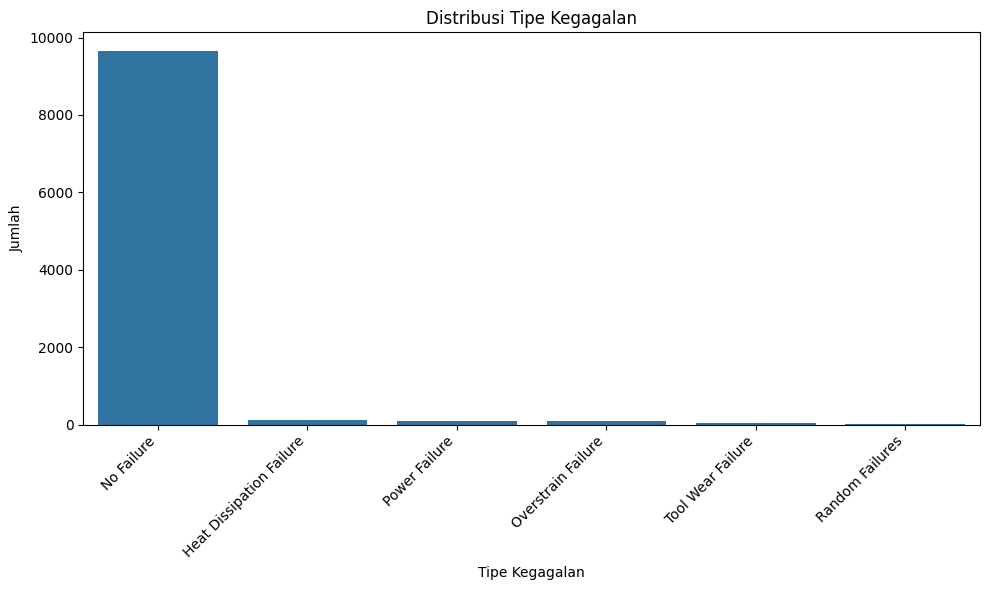

In [5]:
#Cek distirbusi kolom 'Target'
print('Distribusi kolom Target')
print(df['Target'].value_counts())
print('\nPersentase Distribusi kolom Target:')
print(df['Target'].value_counts(normalize=True) * 100)

#Cek distribusi kolom 'Failure Type'
print('\nDistribusi kolom Failure Type')
print(df['Failure Type'].value_counts())
print('\nPersentase Distribusi kolom Failure Type:')
print(df['Failure Type'].value_counts(normalize=True) * 100)

#Visualisasi distribusi 'Failure Type'
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Failure Type', order=df['Failure Type'].value_counts().index)
plt.title('Distribusi Tipe Kegagalan')
plt.xlabel('Tipe Kegagalan')
plt.ylabel('Jumlah')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Korelasi antara Fitur Sensor dan Target:
Air temperature [K]        0.082556
Process temperature [K]    0.035946
Rotational speed [rpm]    -0.044188
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Name: Target, dtype: float64


/tmp/ipykernel_2437/1480650330.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.index, y=correlations.values, palette='viridis')


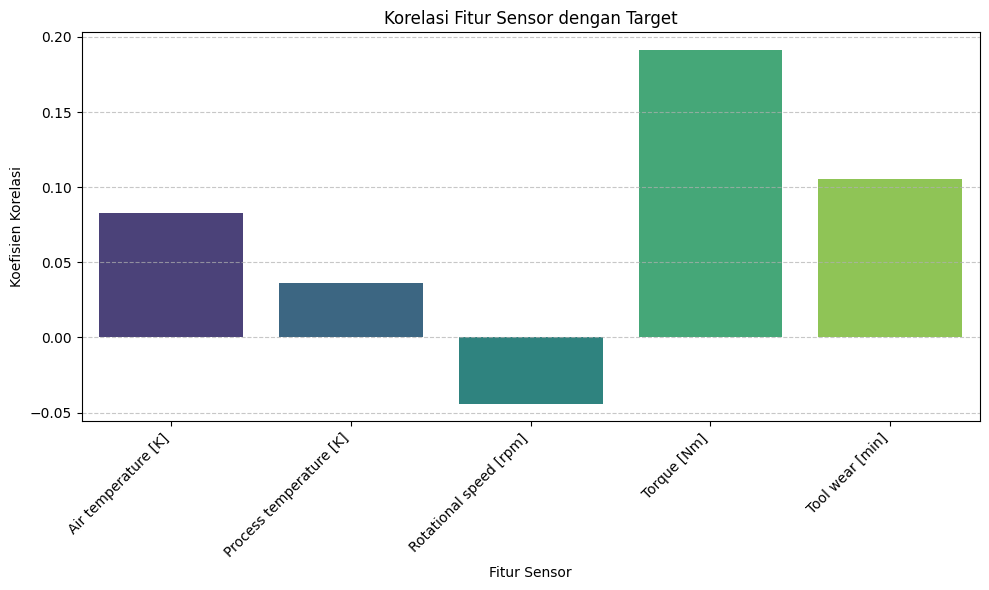

In [6]:
#Memilih kolom sensor numerik dan kolom target
sensor_features = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
target_column = 'Target'

#Menghitung korelasi antara fitur sensor dan Target
correlations = df[sensor_features + [target_column]].corr()[target_column].drop(target_column)

#Menampilkan korelasi dalam bentuk tabel
print("Korelasi antara Fitur Sensor dan Target:")
print(correlations)

#Visualisasi korelasi
plt.figure(figsize=(10, 6))
sns.barplot(x=correlations.index, y=correlations.values, palette='viridis')
plt.title('Korelasi Fitur Sensor dengan Target')
plt.xlabel('Fitur Sensor')
plt.ylabel('Koefisien Korelasi')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Distrbusi kolom Type (Tipe Mesin):
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

Persentase Distribusi kolom Type:
Type
L    60.00
M    29.97
H    10.03
Name: proportion, dtype: float64


/tmp/ipykernel_2437/3680363127.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Type', order=df['Type'].value_counts().index, palette='crest')


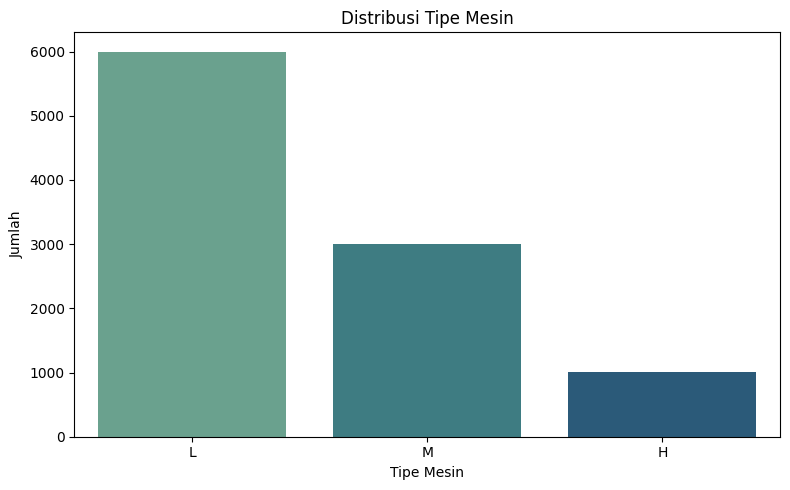

In [7]:
#Cek distribusi kolom 'Type'
print('\nDistrbusi kolom Type (Tipe Mesin):')
print(df['Type'].value_counts())
print('\nPersentase Distribusi kolom Type:')
print(df['Type'].value_counts(normalize=True) * 100)

#Visualisasi distribusi 'Type'
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Type', order=df['Type'].value_counts().index, palette='crest')
plt.title('Distribusi Tipe Mesin')
plt.xlabel('Tipe Mesin')
plt.ylabel('Jumlah')
plt.tight_layout()
plt.show()

## Data Cleaning

1. Menghapus kolom ID yang tidak informatif: UDI dan Product ID tidak menambah nilai prediktif dan bahkan bisa membingungkan model jika tidak ditangani dengan benar.
2. Encoding kolom kategorikal (Type): Model machine learning bekerja paling baik dengan input numerik. Kolom Type ('L', 'M', 'H') adalah kategorikal dan perlu diubah menjadi representasi numerik (misalnya, One-Hot Encoding atau Label Encoding).
3. Pengecekan duplikat/missing value: Duplikat bisa menyebabkan bias dalam training dan validasi model, sementara missing value harus ditangani agar tidak mengganggu proses komputasi dan interpretasi.

In [8]:
# 1. Drop kolom 'UDI dan 'Product ID'
df_cleaned = df.drop(columns=['UDI', 'Product ID'])
print('DataFrame setelah pembersihan kolom:')
print(df_cleaned.head())

# 2. One-Hot Encoding untuk kolom 'Type'
df_cleaned = pd.get_dummies(df_cleaned, columns=['Type'], prefix=['Type'])
print('\nDataFrame setelah One-Hot Encoding:')
print(df_cleaned.head())

# 3. Pengecekan missing values
print('\nJumlah missing values:')
print(df_cleaned.isnull().sum())

# 4. Pengecekan Duplikasi
print('\nJumlah duplikasi:')
print(df_cleaned.duplicated().sum())



DataFrame setelah pembersihan kolom:
  Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0    M                298.1                    308.6                    1551   
1    L                298.2                    308.7                    1408   
2    L                298.1                    308.5                    1498   
3    L                298.2                    308.6                    1433   
4    L                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Target Failure Type  
0         42.8                0       0   No Failure  
1         46.3                3       0   No Failure  
2         49.4                5       0   No Failure  
3         39.5                7       0   No Failure  
4         40.0                9       0   No Failure  

DataFrame setelah One-Hot Encoding:
   Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0                298.1                  

## Feature Engineering

Dalam domain teknik elektro/mesin, ada banyak parameter yang saling berinteraksi dan kombinasi dari parameter tersebut bisa lebih informatif daripada parameter aslinya. Misalnya:

1. Power (Torque × Rotational speed): Daya mekanik yang dihasilkan atau dibutuhkan oleh mesin adalah konsep fundamental di teknik mesin dan elektro. Mesin mungkin lebih rentan gagal ketika beroperasi pada daya tinggi atau ketika terjadi fluktuasi daya yang ekstrem. Jika hanya melihat torsi atau kecepatan rotasi secara terpisah, kita mungkin kehilangan gambaran tentang total beban kerja mesin.
2. Selisih Suhu (Process temp − Air temp): Perbedaan antara suhu proses internal mesin dan suhu udara sekitar (lingkungan) adalah indikator penting dari efisiensi pendinginan atau stres termal pada komponen. Selisih suhu yang besar atau tidak normal bisa mengindikasikan masalah pendinginan, beban berlebih, atau kerusakan pada sensor suhu. Ini jauh lebih informatif daripada hanya melihat kedua suhu tersebut secara terpisah.

Fitur-fitur turunan ini akan memberikan gambaran yang lebih holistik dan relevan secara fisik mengenai kondisi operasional mesin, yang berpotensi meningkatkan kemampuan model untuk memprediksi kegagalan.



In [9]:
# 1. Buat fitur 'Power' (Torque x Rotational speed)
df_cleaned['Power'] = df_cleaned['Torque [Nm]'] * df_cleaned['Rotational speed [rpm]']

# 2. Buat fitur 'Temp Diff' (Process temperature - Air temperature)
df_cleaned['Temp_Diff'] = df_cleaned['Process temperature [K]'] - df_cleaned['Air temperature [K]']

print('DataFrame setelah fitur engineering:')
print(df_cleaned.head())

DataFrame setelah fitur engineering:
   Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0                298.1                    308.6                    1551   
1                298.2                    308.7                    1408   
2                298.1                    308.5                    1498   
3                298.2                    308.6                    1433   
4                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Target Failure Type  Type_H  Type_L  Type_M  \
0         42.8                0       0   No Failure   False   False    True   
1         46.3                3       0   No Failure   False    True   False   
2         49.4                5       0   No Failure   False    True   False   
3         39.5                7       0   No Failure   False    True   False   
4         40.0                9       0   No Failure   False    True   False   

     Power  Temp_Diff  
0  6638

## Split Data & Handling Imbalance



In [10]:
from sklearn.model_selection import train_test_split

# Pisahkan fitur (X) dan target (y)
# Menggunakan 'Failure Type' sebagai target multiclass
X = df_cleaned.drop(columns=['Target', 'Failure Type'])
y = df_cleaned['Failure Type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print('Ukuran X_train:', X_train.shape)
print('Ukuran y_train:', y_train.shape)
print('Ukuran X_test:', X_test.shape)
print('Ukuran y_test:', y_test.shape)

print('\nDistribusi Failure Type di y_train (persentase):')
print(y_train.value_counts(normalize=True) * 100)
print('\nDistribusi Failure Type di y_test (persentase):')
print(y_test.value_counts(normalize=True) * 100)

Ukuran X_train: (8000, 10)
Ukuran y_train: (8000,)
Ukuran X_test: (2000, 10)
Ukuran y_test: (2000,)

Distribusi Failure Type di y_train (persentase):
Failure Type
No Failure                  96.525
Heat Dissipation Failure     1.125
Power Failure                0.950
Overstrain Failure           0.775
Tool Wear Failure            0.450
Random Failures              0.175
Name: proportion, dtype: float64

Distribusi Failure Type di y_test (persentase):
Failure Type
No Failure                  96.50
Heat Dissipation Failure     1.10
Power Failure                0.95
Overstrain Failure           0.80
Tool Wear Failure            0.45
Random Failures              0.20
Name: proportion, dtype: float64


In [11]:
from sklearn.utils import class_weight
import numpy as np

#Hitung bobot kelas untuk y_train
#'balanced' akan otomatis menghitung bobot berdasarkan frekuensi kelas
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

#Buat dictionary bobot kelas
class_weight_dict = dict(zip(np.unique(y_train), class_weights))

print('Bobot kelas untuk y_train:')
print(class_weight_dict)

Bobot kelas untuk y_train:
{'Heat Dissipation Failure': np.float64(14.814814814814815), 'No Failure': np.float64(0.172666839333506), 'Overstrain Failure': np.float64(21.50537634408602), 'Power Failure': np.float64(17.54385964912281), 'Random Failures': np.float64(95.23809523809524), 'Tool Wear Failure': np.float64(37.03703703703704)}


## Modeling

 Mulai dengan membuat baseline model menggunakan Logistic Regression dan menerapkan class_weight yang sudah kita hitung. Logistic Regression adalah pilihan yang baik sebagai baseline karena relatif sederhana, cepat dilatih, dan memberikan gambaran awal tentang seberapa baik fitur bekerja.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Inisialisasi model Logistic Regression dengan class_weight
# solver='liblinear' cocok untuk dataset kecil dan multinomial (multiclass)
# max_iter ditingkatkan untuk memastikan konvergensi
# random_state untuk reproduktibilitas
model_lr_cw = LogisticRegression(
    solver='liblinear',
    multi_class='ovr', # One-vs-Rest, cocok untuk multiclass imbalanced
    class_weight=class_weight_dict, # Menggunakan bobot kelas yang sudah dihitung
    max_iter=1000,
    random_state=42
)

#Latih model pada data training
model_lr_cw.fit(X_train, y_train)

#Lakukan prediksi pada data test
y_pred_lr_cw = model_lr_cw.predict(X_test)

#Tampilkan classification report
print('\nClassification Report (Logistic Regression dengan class_weight):')
print(classification_report(y_test, y_pred_lr_cw))

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(



Classification Report (Logistic Regression dengan class_weight):
                          precision    recall  f1-score   support

Heat Dissipation Failure       0.42      0.86      0.57        22
              No Failure       0.99      0.96      0.98      1930
      Overstrain Failure       0.53      1.00      0.70        16
           Power Failure       0.54      0.79      0.64        19
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       0.00      0.00      0.00         9

                accuracy                           0.96      2000
               macro avg       0.41      0.60      0.48      2000
            weighted avg       0.97      0.96      0.96      2000



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


* Precision (Presisi): Mengukur seberapa
akurat prediksi positif model. Untuk kelas 'Random Failures', Precision 0.00 berarti bahwa dari semua instance yang diprediksi oleh model sebagai 'Random Failures', tidak ada satupun yang benar-benar 'Random Failures'. Dalam kasus ini, ini juga bisa berarti bahwa model tidak pernah memprediksi adanya 'Random Failures'.
* Recall (Sensitivitas): Mengukur kemampuan model untuk menemukan semua instance positif. Untuk kelas 'Random Failures', Recall 0.00 berarti bahwa model gagal mengidentifikasi satupun dari semua instance 'Random Failures' yang sebenarnya ada dalam data uji.
Secara umum, nilai 0.00 untuk Precision dan Recall pada 'Random Failures' serta 'Tool Wear Failure' mengindikasikan bahwa model Logistic Regression kita sama sekali tidak berhasil mendeteksi kedua jenis kegagalan ini. Ini adalah masalah umum pada dataset yang sangat imbalanced.

Analisis Hasil classification_report:

1. Akurasi (Accuracy): 0.96. Angka ini terlihat tinggi, namun bisa menyesatkan karena didominasi oleh kelas 'No Failure' yang sangat banyak (mayoritas). Model mungkin hanya pandai memprediksi 'No Failure' dan mengabaikan kelas-kelas kegagalan lainnya.
2. Kelas 'No Failure': Memiliki precision, recall, dan f1-score yang sangat tinggi (sekitar 0.98-0.99). Ini wajar karena kelas ini adalah mayoritas, dan model mudah mengidentifikasinya.
3. Kelas Kegagalan Minoritas ('Heat Dissipation', 'Overstrain', 'Power Failure'): Model menunjukkan sedikit kemampuan deteksi:
  * Heat Dissipation Failure: Precision 0.42, Recall 0.86. Artinya, model bisa mendeteksi sebagian besar (86%) kegagalan ini, tetapi 58% dari yang diprediksi sebagai 'Heat Dissipation Failure' sebenarnya bukan.
  * Overstrain Failure: Precision 0.53, Recall 1.00. Ini luar biasa karena model berhasil mendeteksi semua (100%) kegagalan ini, meskipun 47% prediksi positifnya salah.
  * Power Failure: Precision 0.54, Recall 0.79. Mirip dengan Heat Dissipation.
4. Kelas Kegagalan Sangat Minoritas ('Random Failures', 'Tool Wear Failure'): Seperti yang sudah kita bahas, model gagal total (Precision, Recall, f1-score = 0.00) untuk mendeteksi kedua jenis kegagalan ini. Ini sangat kritis karena 'Random Failures' adalah yang paling jarang dan mungkin yang paling sulit diprediksi, tetapi berpotensi memiliki dampak signifikan jika tidak terdeteksi.

Kesimpulan Awal: Baseline model Logistic Regression ini, meskipun menggunakan class_weight, masih belum mampu menangani kelas-kelas kegagalan yang sangat minoritas. Ini menunjukkan bahwa kita perlu eksplorasi lebih lanjut untuk meningkatkan kemampuan deteksi model terhadap kegagalan-kegagalan langka.

Langkah Selanjutnya:

Untuk Tahap 6 — Modeling, hasil ini mengindikasikan bahwa hanya menggunakan class_weight belum cukup untuk mengatasi extreme class imbalance, terutama untuk Random Failures dan Tool Wear Failure.

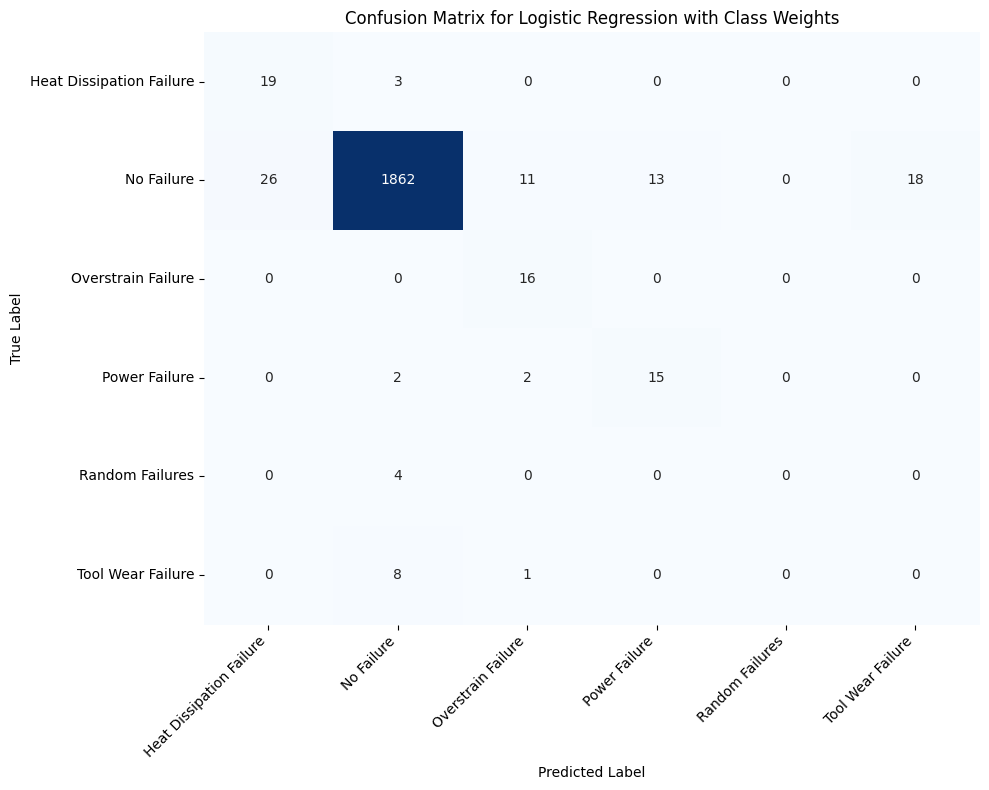

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Hitung confusion matrix
cm = confusion_matrix(y_test, y_pred_lr_cw, labels=np.unique(y_test))

# Buat DataFrame dari confusion matrix untuk visualisasi yang lebih baik
cm_df = pd.DataFrame(cm, index=np.unique(y_test), columns=np.unique(y_test))

# Visualisasikan confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.title('Confusion Matrix for Logistic Regression with Class Weights')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight dari Confusion Matrix:**

1. 'No Failure' (Kelas Mayoritas): Terlihat sangat baik. Diagonal utama untuk 'No Failure' (True Label: 'No Failure', Predicted Label: 'No Failure') menunjukkan angka 1862. Ini berarti sebagian besar kasus 'tidak ada kegagalan' diprediksi dengan benar. Namun, ada beberapa misklasifikasi kecil, misalnya 26 kasus 'No Failure' yang diprediksi sebagai 'Heat Dissipation Failure', 11 sebagai 'Overstrain Failure', 13 sebagai 'Power Failure', dan 18 sebagai 'Tool Wear Failure'.

2. 'Heat Dissipation Failure': Dari 22 kejadian 'Heat Dissipation Failure' yang sebenarnya, 19 berhasil diprediksi dengan benar (diagonal utama). Ada 3 kasus yang salah diprediksi sebagai 'No Failure'. Ini selaras dengan recall yang cukup baik (0.86) yang kita lihat di classification_report.

3. 'Overstrain Failure': Semua 16 kejadian 'Overstrain Failure' berhasil diprediksi dengan benar (diagonal utama). Ini menghasilkan recall 1.00, seperti yang terlihat sebelumnya.

4. 'Power Failure': Dari 19 kejadian 'Power Failure' yang sebenarnya, 15 berhasil diprediksi dengan benar. Ada 2 kasus yang salah diprediksi sebagai 'No Failure' dan 2 sebagai 'Overstrain Failure'.

5. 'Random Failures': Ini adalah poin kritis. Baris 'Random Failures' (True Label) menunjukkan bahwa ada 4 kejadian 'Random Failures' yang sebenarnya. Namun, tidak ada satu pun dari 4 kejadian ini yang diprediksi dengan benar sebagai 'Random Failures'. Semua 4 kasus ini salah diprediksi sebagai 'No Failure'. Ini menjelaskan mengapa Precision dan Recall untuk 'Random Failures' adalah 0.00.

4. 'Tool Wear Failure': Sama seperti 'Random Failures', baris 'Tool Wear Failure' menunjukkan ada 9 kejadian sebenarnya. Tidak ada satu pun yang diprediksi dengan benar. Sebanyak 8 kasus salah diprediksi sebagai 'No Failure', dan 1 kasus salah diprediksi sebagai 'Overstrain Failure'. Ini juga menjelaskan Precision dan Recall 0.00.

**Kesimpulan dari Confusion Matrix:** Confusion Matrix dengan jelas memvisualisasikan bahwa model Logistic Regression kita benar-benar tidak dapat mendeteksi 'Random Failures' dan 'Tool Wear Failure'. Ini adalah masalah serius karena kedua tipe kegagalan ini, meskipun jarang, bisa jadi yang paling penting untuk dideteksi dalam skenario pemeliharaan prediktif.

Fakta bahwa semua kegagalan minoritas yang tidak terdeteksi akhirnya diprediksi sebagai 'No Failure' menunjukkan bias yang kuat terhadap kelas mayoritas, meskipun kita sudah menggunakan class_weight. Ini mengindikasikan bahwa class_weight saja mungkin tidak cukup untuk dataset dengan extreme class imbalance seperti ini.

**Langkah Selanjutnya:**

Karena class_weight saja tidak cukup efektif untuk mengatasi ketidakseimbangan kelas yang ekstrem pada 'Random Failures' dan 'Tool Wear Failure', kita perlu mencoba pendekatan lain. Sesuai rencana proyek, kita akan mencoba SMOTE (Synthetic Minority Over-sampling Technique). SMOTE bekerja dengan membuat sampel sintetis dari kelas minoritas untuk menyeimbangkan distribusi kelas, yang diharapkan dapat membantu model belajar pola dari kelas-kelas yang jarang ini.

In [14]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print('Distribusi kelas sebelum SMOTE:', Counter(y_train))

#Inisialisasi SMOTE
smote = SMOTE(random_state=42)

#Lakukan oversampling pada data training
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


print('Distribusi kelas setelah SMOTE:', Counter(y_train_smote))

# Latih ulang model Logistic Regression dengan data yang sudah di-SMOTE
# Kali ini kita tidak perlu class_weight karena SMOTE sudah menyeimbangkan data
model_lr_smote = LogisticRegression(
    solver='liblinear',
    multi_class='ovr',
    max_iter=1000,
    random_state=42
)

model_lr_smote.fit(X_train_smote, y_train_smote)

#Lakukan prediksi pada data test
y_pred_lr_smote = model_lr_smote.predict(X_test)

#Tampilkan classification report
print('\nClassification Report (Logistic Regression dengan SMOTE):')
print(classification_report(y_test, y_pred_lr_smote))


Distribusi kelas sebelum SMOTE: Counter({'No Failure': 7722, 'Heat Dissipation Failure': 90, 'Power Failure': 76, 'Overstrain Failure': 62, 'Tool Wear Failure': 36, 'Random Failures': 14})
Distribusi kelas setelah SMOTE: Counter({'No Failure': 7722, 'Tool Wear Failure': 7722, 'Random Failures': 7722, 'Power Failure': 7722, 'Heat Dissipation Failure': 7722, 'Overstrain Failure': 7722})


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(



Classification Report (Logistic Regression dengan SMOTE):
                          precision    recall  f1-score   support

Heat Dissipation Failure       0.08      0.91      0.15        22
              No Failure       1.00      0.66      0.79      1930
      Overstrain Failure       0.34      0.94      0.50        16
           Power Failure       0.22      0.95      0.35        19
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       0.06      0.89      0.11         9

                accuracy                           0.67      2000
               macro avg       0.28      0.72      0.32      2000
            weighted avg       0.97      0.67      0.77      2000



**Analisis Hasil classification_report (Logistic Regression dengan SMOTE):**

Perhatikan perbedaan distribusi kelas sebelum dan sesudah SMOTE yang sudah tercetak. Semua kelas minoritas sekarang memiliki jumlah sampel yang sama dengan kelas mayoritas (No Failure) di data training.

Sekarang mari kita lihat classification_report yang baru:

1. Akurasi (Accuracy): Turun drastis dari 0.96 menjadi 0.67. Penurunan akurasi ini seringkali terjadi saat kita mencoba menyeimbangkan data, karena model tidak lagi didominasi oleh kelas mayoritas. Namun, ini adalah tanda yang baik bahwa model mulai mencoba mempelajari kelas-kelas minoritas.

2. Kelas 'No Failure': Recall-nya turun drastis dari 0.96 menjadi 0.66, sementara Precision-nya tetap tinggi (1.00). Ini berarti model sekarang cenderung lebih jarang memprediksi 'No Failure' dan banyak kasus 'No Failure' yang sebenarnya justru diprediksi sebagai jenis kegagalan lain.

3. Kelas Kegagalan Minoritas ('Heat Dissipation', 'Overstrain', 'Power Failure', 'Tool Wear Failure'):

  * Recall untuk kelas-kelas ini meningkat signifikan! Contohnya, Heat Dissipation Failure Recall-nya dari 0.86 menjadi 0.91, Overstrain Failure dari 1.00 menjadi 0.94, Power Failure dari 0.79 menjadi 0.95, dan yang paling dramatis Tool Wear Failure dari 0.00 menjadi 0.89.
  * Namun, Precision untuk kelas-kelas ini turun drastis. Misalnya, Heat Dissipation Failure Precision-nya dari 0.42 menjadi 0.08. Ini berarti model sekarang lebih sering memprediksi kelas-kelas kegagalan ini, tetapi banyak dari prediksi tersebut salah.
4. 'Random Failures': Sayangnya, Random Failures masih memiliki Precision dan Recall 0.00. Meskipun SMOTE sudah diterapkan, model ini masih gagal mendeteksi 'Random Failures' di data test.

**Kesimpulan Sementara:** SMOTE berhasil meningkatkan kemampuan model untuk menemukan (Recall) sebagian besar jenis kegagalan yang sebelumnya terabaikan, terutama Tool Wear Failure! Ini adalah peningkatan yang signifikan. Namun, Trade-offnya adalah Precision yang sangat rendah untuk kelas-kelas minoritas, dan Random Failures masih menjadi tantangan besar.

Untuk mendapatkan gambaran visual yang lebih jelas tentang bagaimana SMOTE mengubah pola kesalahan prediksi, mari kita tampilkan Confusion Matrix untuk model Logistic Regression yang dilatih dengan data yang sudah di-SMOTE.

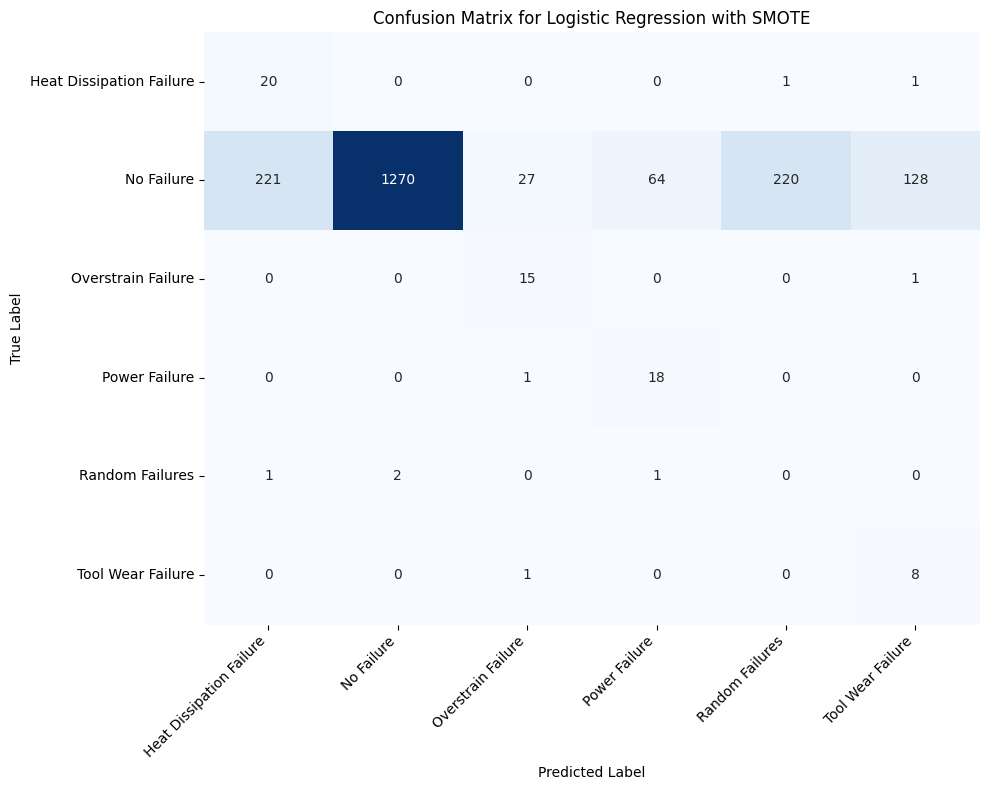

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np # Pastikan numpy diimpor

# Hitung confusion matrix untuk model SMOTE
cm_smote = confusion_matrix(y_test, y_pred_lr_smote, labels=np.unique(y_test))

# Buat DataFrame dari confusion matrix untuk visualisasi yang lebih baik
cm_df_smote = pd.DataFrame(cm_smote, index=np.unique(y_test), columns=np.unique(y_test))

# Visualisasikan confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_df_smote, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.title('Confusion Matrix for Logistic Regression with SMOTE')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Perbedaan Utama Confusion Matrix (Tanpa SMOTE vs. Dengan SMOTE):**

1. Penurunan Prediksi Benar untuk 'No Failure' (Kelas Mayoritas):

  * Tanpa SMOTE: Model sangat baik dalam memprediksi 'No Failure' dengan 1862 kasus yang benar terklasifikasi sebagai 'No Failure'.
  * Dengan SMOTE: Angka ini turun drastis menjadi 1270. Ini adalah trade-off yang paling jelas. Model kini tidak lagi terlalu bias ke kelas mayoritas. Banyak kasus 'No Failure' yang sebenarnya (true label 'No Failure') kini justru diprediksi sebagai jenis kegagalan lain (misalnya, 221 diprediksi sebagai 'Heat Dissipation Failure', 220 sebagai 'Random Failures', dan 128 sebagai 'Tool Wear Failure'). Ini menjelaskan mengapa recall untuk 'No Failure' turun signifikan, dan precision untuk kelas minoritas menjadi rendah (banyak False Positives).
2. Peningkatan Deteksi (Recall) untuk Kelas Minoritas Tertentu:

  * 'Tool Wear Failure': Ini adalah peningkatan paling mencolok! Sebelumnya, model gagal total (0 kasus terdeteksi) untuk 'Tool Wear Failure'. Sekarang, 8 dari 9 kasus 'Tool Wear Failure' yang sebenarnya berhasil terdeteksi dengan benar (diagonal utama). Ini menunjukkan SMOTE sangat membantu model 'melihat' pola dari jenis kegagalan ini.
  * 'Heat Dissipation Failure': Meningkat sedikit dari 19 menjadi 20 kasus yang terdeteksi dengan benar.
  * 'Power Failure': Meningkat dari 15 menjadi 18 kasus yang terdeteksi dengan benar.
3. Peningkatan False Positives untuk Kelas Minoritas:

  * Meski recall meningkat, precision untuk kelas minoritas justru menurun drastis. Ini terlihat dari angka-angka di kolom 'Heat Dissipation Failure', 'Overstrain Failure', 'Power Failure', dan 'Tool Wear Failure' pada baris 'No Failure'. Artinya, model sekarang lebih sering memprediksi adanya kegagalan, tetapi seringkali prediksi tersebut salah (bukan kegagalan yang sebenarnya, melainkan 'No Failure').

4. 'Random Failures' Masih Menjadi Tantangan:

  * Dari 4 kasus 'Random Failures' yang sebenarnya, tidak ada satu pun yang berhasil diprediksi dengan benar sebagai 'Random Failures' (diagonal utama masih 0). Kasus 'Random Failures' masih tersebar, diprediksi sebagai 'Heat Dissipation Failure' (1), 'No Failure' (2), atau 'Power Failure' (1). Ini mengindikasikan bahwa 'Random Failures' mungkin adalah kelas yang sangat unik atau tidak memiliki fitur yang cukup jelas bahkan setelah di-oversample.

**Kesimpulan dari Kedua Confusion Matrix:**

SMOTE berhasil membuat model lebih sensitif terhadap kelas-kelas kegagalan minoritas, terutama 'Tool Wear Failure', yang sebelumnya sama sekali tidak terdeteksi. Namun, trade-off-nya adalah akurasi keseluruhan model menurun, dan model menjadi lebih rentan terhadap false positives (memprediksi kegagalan padahal tidak ada) untuk kelas 'No Failure'. Tantangan terbesar tetap pada 'Random Failures' yang masih belum bisa dideteksi oleh model Logistic Regression ini.

**Langkah Selanjutnya: Meningkatkan Kemampuan Deteksi Kegagalan**

Random Forest adalah model ensemble yang seringkali sangat efektif, terutama pada dataset dengan banyak fitur dan kompleksitas. Model ini juga memiliki mekanisme bawaan untuk menangani imbalanced data dengan baik, dan kita bisa menerapkan class_weight lagi di dalamnya, atau bahkan menggabungkan dengan SMOTE jika diperlukan.



Classification Report (Random Forest dengan class_weight):
                          precision    recall  f1-score   support

Heat Dissipation Failure       0.96      1.00      0.98        22
              No Failure       0.99      0.98      0.99      1930
      Overstrain Failure       0.80      0.75      0.77        16
           Power Failure       1.00      1.00      1.00        19
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       0.05      0.22      0.08         9

                accuracy                           0.97      2000
               macro avg       0.63      0.66      0.64      2000
            weighted avg       0.98      0.97      0.98      2000



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


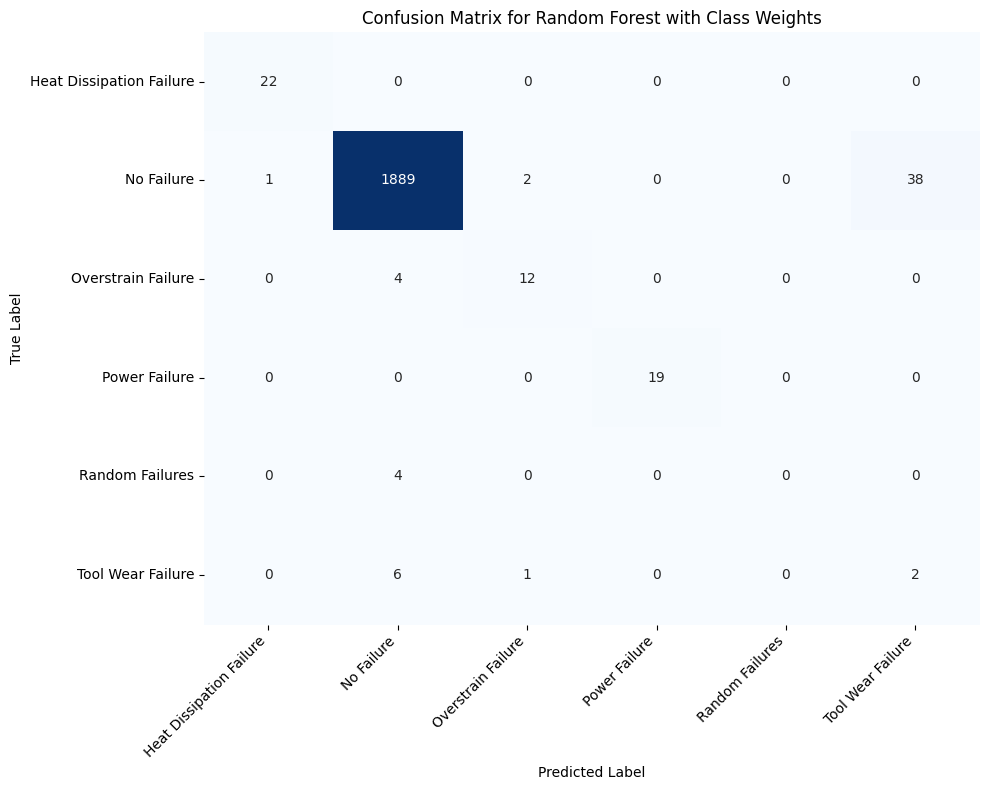

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Inisialisasi model Random Forest dengan class_weight
model_rf_cw = RandomForestClassifier(
    n_estimators=100, # Jumlah pohon dalam forest
    class_weight=class_weight_dict, # Menggunakan bobot kelas yang sudah dihitung
    random_state=42,
    max_depth=10 # Kedalaman maksimum setiap pohon
)

# Latih model pada data training
model_rf_cw.fit(X_train, y_train)

# Lakukan prediksi pada data test
y_pred_rf_cw = model_rf_cw.predict(X_test)

#Tampilkan classification report
print('\nClassification Report (Random Forest dengan class_weight):')
print(classification_report(y_test, y_pred_rf_cw))

#Visualisasi Confusion Matrix
cm_rf_cw = confusion_matrix(y_test, y_pred_rf_cw, labels=np.unique(y_test))
cm_df_rf_cw = pd.DataFrame(cm_rf_cw, index=np.unique(y_test), columns=np.unique(y_test))

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df_rf_cw, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.title('Confusion Matrix for Random Forest with Class Weights')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Perbandingan dengan Logistic Regression (LR) sebelumnya:**

1. Secara Keseluruhan: Random Forest dengan class_weight menunjukkan peningkatan signifikan dalam mendeteksi mayoritas tipe kegagalan minoritas dibandingkan Logistic Regression dengan class_weight. Akurasi keseluruhan Random Forest lebih tinggi (0.97) dan makro rata-rata F1-score (0.64) juga lebih baik daripada LR dengan class_weight (0.48).

2. Heat Dissipation Failure & Power Failure: Random Forest jauh lebih superior. LR dengan class_weight memiliki Recall 0.86 (Heat Dissipation) dan 0.79 (Power Failure), sedangkan Random Forest mencapai 1.00 untuk keduanya. Ini adalah peningkatan besar!

3. Overstrain Failure: Random Forest (Recall 0.75) sedikit menurun dibandingkan LR dengan class_weight (Recall 1.00), namun Random Forest memiliki Precision yang lebih baik (0.80 vs 0.53) untuk kelas ini, yang berarti lebih sedikit False Positives.

4. No Failure: Keduanya sangat baik dalam memprediksi 'No Failure'. Random Forest menunjukkan sedikit lebih banyak False Positives (memprediksi kegagalan padahal 'No Failure') dibandingkan LR dengan class_weight (misalnya, 38 'No Failure' diprediksi sebagai 'Tool Wear Failure' di RF, dibandingkan dengan 18 di LR).

5. Random Failures & Tool Wear Failure:

  * Random Failures: Sayangnya, kedua model (LR dengan class_weight, LR dengan SMOTE, dan Random Forest dengan class_weight) sama-sama gagal total dalam mendeteksi 'Random Failures' (Recall 0.00). Ini menunjukkan bahwa kelas ini mungkin sangat sulit untuk diprediksi dengan fitur yang ada atau perlu pendekatan yang lebih canggih.
  * Tool Wear Failure: Random Forest (Recall 0.22) masih jauh tertinggal dari Logistic Regression dengan SMOTE (Recall 0.89). Ini menarik karena SMOTE justru sangat membantu LR dalam mendeteksi 'Tool Wear Failure' secara agresif, meskipun dengan Precision yang rendah.

**Kesimpulan Sementara:**

Random Forest dengan class_weight memberikan hasil yang jauh lebih baik untuk sebagian besar tipe kegagalan minoritas dibandingkan Logistic Regression dengan class_weight. Namun, 'Random Failures' tetap menjadi kelas yang tidak terdeteksi oleh kedua model ini. Menariknya, untuk 'Tool Wear Failure', pendekatan SMOTE pada Logistic Regression justru lebih efektif dalam meningkatkan Recall. Ini mengindikasikan bahwa kombinasi teknik mungkin diperlukan, atau penyesuaian parameter yang lebih mendalam pada Random Forest.

**Modeling dengan Random Forest dan SMOTE**

Selanjutnya, kita akan melatih model Random Forest menggunakan data training yang sudah di-oversample dengan SMOTE. Tujuannya adalah untuk melihat apakah kombinasi Random Forest dan SMOTE dapat memberikan hasil yang lebih baik, terutama dalam mendeteksi kelas-kelas minoritas yang sulit.

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Inisialisasi model Random Forest
# Kali ini kita tidak perlu class_weight karena SMOTE sudah menyeimbangkan data training
model_rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10 # Gunakan kedalaman yang sama untuk perbandingan yang adil
)

# Latih model pada data training yang sudah di-SMOTE
model_rf_smote.fit(X_train_smote, y_train_smote)

# Lakukan prediksi pada data test (ingat, data test tidak di-SMOTE)
y_pred_rf_smote = model_rf_smote.predict(X_test)

# Tampilkan classification report
print('\nClassification Report (Random Forest dengan SMOTE):')
print(classification_report(y_test, y_pred_rf_smote))


Classification Report (Random Forest dengan SMOTE):
                          precision    recall  f1-score   support

Heat Dissipation Failure       0.95      0.91      0.93        22
              No Failure       0.99      0.91      0.95      1930
      Overstrain Failure       0.67      1.00      0.80        16
           Power Failure       1.00      1.00      1.00        19
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       0.04      0.22      0.06         9

                accuracy                           0.91      2000
               macro avg       0.61      0.67      0.62      2000
            weighted avg       0.98      0.91      0.94      2000



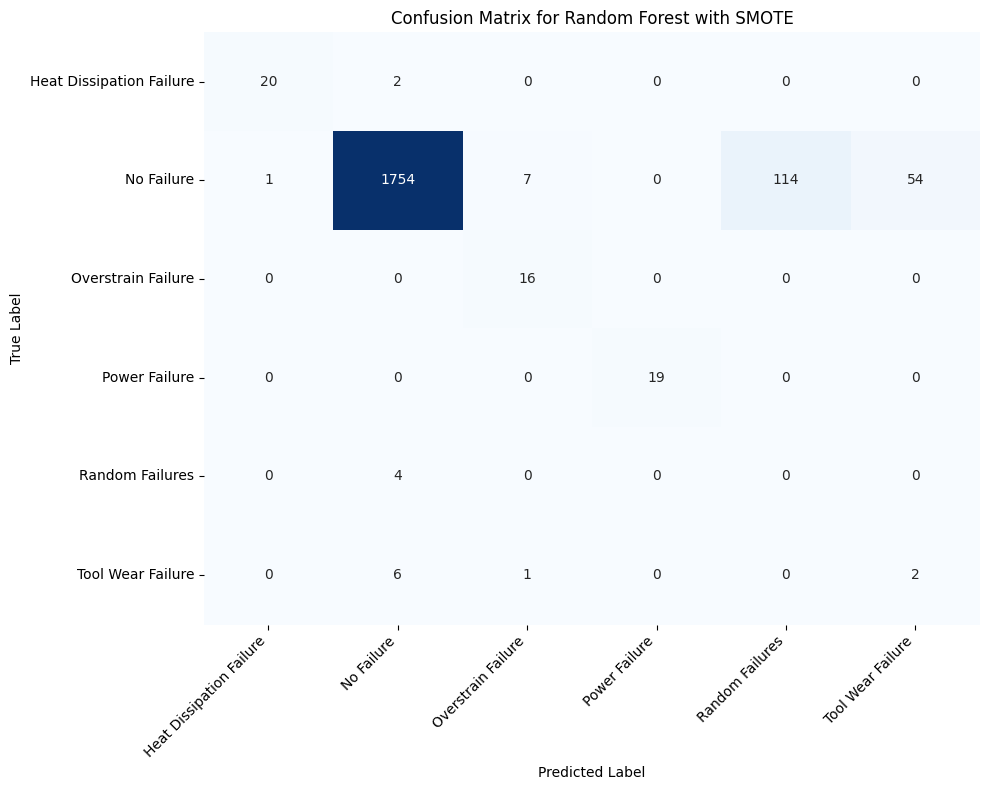

In [18]:
# Visualisasi Confusion Matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cm_rf_smote = confusion_matrix(y_test, y_pred_rf_smote, labels=np.unique(y_test))
cm_df_rf_smote = pd.DataFrame(cm_rf_smote, index=np.unique(y_test), columns=np.unique(y_test))

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df_rf_smote, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.title('Confusion Matrix for Random Forest with SMOTE')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Perbandingan dengan Model Sebelumnya:**

1. Vs. Random Forest dengan class_weight:

  * Keunggulan RF + CW: RF dengan class_weight memiliki akurasi keseluruhan yang lebih tinggi (0.97 vs 0.91) dan mendeteksi 'Heat Dissipation Failure' serta 'Tool Wear Failure' dengan sedikit lebih baik (Recall 'Heat Dissipation Failure' 1.00 vs 0.91, 'Tool Wear Failure' 0.22 vs 0.22 - sama, tapi Precision RF+CW lebih tinggi). RF+CW juga memiliki 'false positive' yang lebih rendah untuk 'No Failure'.
  * RF + SMOTE: Lebih agresif dalam mencoba mendeteksi kelas minoritas, terlihat dari peningkatan 'false positives' dari 'No Failure' ke kelas minoritas. Namun, ini tidak selalu menghasilkan deteksi yang lebih baik untuk semua kelas minoritas.

2. Vs. Logistic Regression dengan SMOTE:

  * RF + SMOTE lebih baik secara keseluruhan: Akurasi lebih tinggi (0.91 vs 0.67) dan F1-score makro rata-rata lebih baik (0.62 vs 0.32).
  * Random Failures: Kedua model masih gagal mendeteksi 'Random Failures'.
  * Tool Wear Failure: LR dengan SMOTE jauh lebih baik dalam mendeteksi 'Tool Wear Failure' (Recall 0.89 vs 0.22), meskipun dengan Precision yang sangat rendah. Ini menunjukkan bahwa SMOTE lebih efektif dalam mendorong LR untuk 'melihat' 'Tool Wear Failure' dibandingkan dengan Random Forest.

**Kesimpulan Akhir Mengenai Random Forest dengan SMOTE:**

Random Forest dengan SMOTE menunjukkan kinerja yang kuat untuk mendeteksi 'Heat Dissipation Failure', 'Overstrain Failure', dan 'Power Failure'. Namun, seperti model-model sebelumnya, 'Random Failures' masih menjadi tantangan yang belum teratasi. Yang menarik, untuk 'Tool Wear Failure', pendekatan SMOTE tampaknya lebih cocok dengan Logistic Regression daripada Random Forest, karena LR dengan SMOTE mencapai Recall yang jauh lebih tinggi. Ini mengindikasikan bahwa jenis model juga berperan besar dalam bagaimana SMOTE memengaruhi kinerja deteksi kelas minoritas.


## Observasi Kunci:

1. 'Random Failures' (Kelas Paling Minoritas): Ini adalah tantangan terbesar. Tidak ada satu pun model yang berhasil mendeteksi 'Random Failures', bahkan setelah menggunakan class_weight atau SMOTE. Ini menunjukkan bahwa kelas ini mungkin terlalu langka, atau fitur-fitur yang ada tidak cukup diskriminatif untuk pola 'Random Failures'.
2. 'Tool Wear Failure': Logistic Regression dengan SMOTE secara mengejutkan adalah yang paling efektif dalam meningkatkan Recall untuk 'Tool Wear Failure' (0.89), meskipun dengan trade-off Precision yang sangat rendah dan penurunan akurasi keseluruhan. Random Forest, baik dengan class_weight maupun SMOTE, menunjukkan kinerja yang kurang baik untuk kelas ini.
3. Kinerja Random Forest: Secara umum, Random Forest dengan class_weight memberikan keseimbangan terbaik antara akurasi keseluruhan dan kemampuan mendeteksi sebagian besar kelas minoritas (kecuali 'Random Failures' dan 'Tool Wear Failure'). Ia berhasil mempertahankan akurasi tinggi sambil meningkatkan deteksi untuk 'Heat Dissipation Failure', 'Overstrain Failure', dan 'Power Failure' dibandingkan Logistic Regression tanpa SMOTE.
4. Dampak SMOTE: SMOTE efektif dalam meningkatkan Recall untuk kelas minoritas yang sebelumnya terabaikan (terutama 'Tool Wear Failure' pada Logistic Regression), tetapi seringkali dengan harga Precision yang rendah (banyak False Positives) dan penurunan drastis pada Recall kelas mayoritas ('No Failure'), serta akurasi keseluruhan. Pada Random Forest, SMOTE tidak memberikan peningkatan yang signifikan dibandingkan class_weight untuk kelas minoritas yang sulit dan bahkan menurunkan kinerja keseluruhan.

### 6.1 Pelengkapan Model : Random Forest dengan Feature Importance


Classification Report (Random Forest dengan Feature Importance):
                          precision    recall  f1-score   support

Heat Dissipation Failure       0.96      1.00      0.98        22
              No Failure       0.99      0.98      0.99      1930
      Overstrain Failure       0.80      0.75      0.77        16
           Power Failure       1.00      1.00      1.00        19
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       0.05      0.22      0.08         9

                accuracy                           0.97      2000
               macro avg       0.63      0.66      0.64      2000
            weighted avg       0.98      0.97      0.98      2000


Urutan fitur berdasarkan bobot:
                   Feature  Importance
4          Tool wear [min]    0.226968
8                    Power    0.206103
9                Temp_Diff    0.163239
3              Torque [Nm]    0.151344
2   Rotational speed [rpm]    0.124104
1  P

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/tmp/ipykernel_2437/1702796418.py:38: FutureWarni

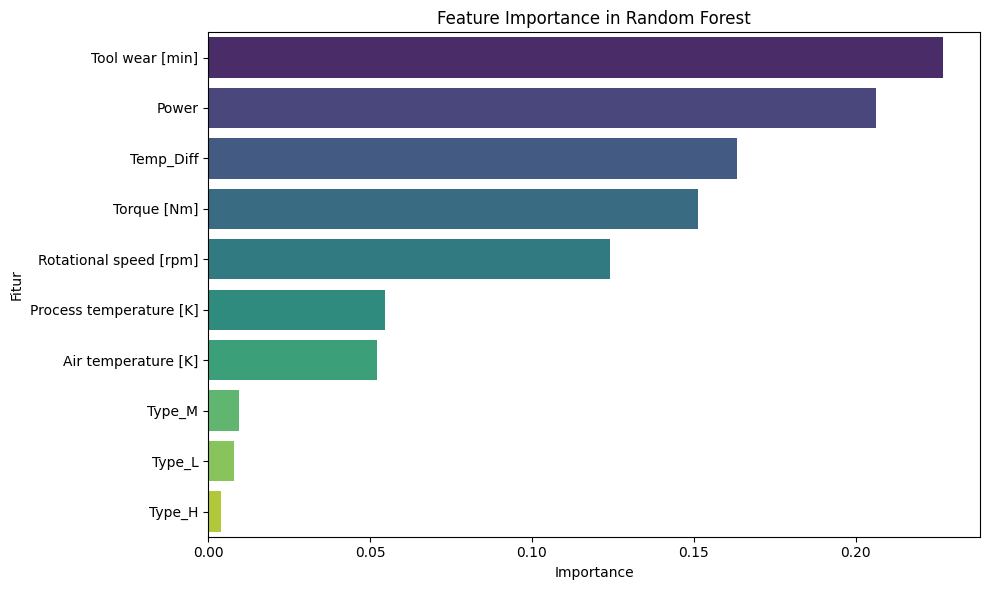

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Inisialisasi model Random Forest
# Kali ini kita tidak perlu class_weight karena SMOTE sudah menyeimbangkan data training
model_rf_fi = RandomForestClassifier(
    n_estimators=100,
    random_state = 42,
    max_depth = 10,
    class_weight = class_weight_dict # Menggunakan class weight yang sudah ada (no SMOTE)
)
# Latih model pada data train
model_rf_fi.fit(X_train, y_train)

# Lakukan prediksi pada data test
y_pred_rf_fi = model_rf_fi.predict(X_test)

# Tampilkan classification report
print('\nClassification Report (Random Forest dengan Feature Importance):')
print(classification_report(y_test, y_pred_rf_fi))

#Hitung dan tampilkan Feature Importance
feature_importances = model_rf_fi.feature_importances_
features = X_train.columns

# Urutkan fitur berdasarkan bobot
importance_df = pd.DataFrame({
    'Feature' : features,
    'Importance' : feature_importances
})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print('\nUrutan fitur berdasarkan bobot:')
print(importance_df)

#Visualisasi Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importance in Random Forest')
plt.xlabel('Importance')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

## Laporan Analisis Model Prediktif untuk Predictive Maintenance

Laporan ini merinci hasil evaluasi beberapa model klasifikasi yang bertujuan untuk memprediksi tipe kegagalan pada mesin. Fokus utama adalah mengidentifikasi model terbaik yang mampu mendeteksi jenis-jenis kegagalan, terutama yang bersifat minoritas dan berdampak kritis.

### Ringkasan Eksekutif

Analisis menunjukkan bahwa **Random Forest dengan `class_weight`** memberikan kinerja keseluruhan terbaik dalam mendeteksi sebagian besar tipe kegagalan minoritas, dengan akurasi dan presisi yang tinggi untuk `Heat Dissipation Failure` dan `Power Failure`. Namun, `Random Failures` tetap menjadi tantangan serius bagi semua model, dan `Tool Wear Failure` menunjukkan sensitivitas yang lebih baik pada Logistic Regression dengan SMOTE.

### Evaluasi Model

Kami telah mengevaluasi tiga pendekatan utama:

#### 1. Logistic Regression dengan `class_weight` (Model Baseline)

*   **Kelebihan:**
    *   **Performa Kuat untuk Kelas Mayoritas:** Sangat efektif dalam mengidentifikasi kondisi `No Failure` (Akurasi 0.96, Precision dan Recall ~0.98).
    *   **Deteksi Kelas Minoritas Tertentu:** Menunjukkan kemampuan deteksi yang baik untuk `Overstrain Failure` (Recall 1.00) dan cukup baik untuk `Heat Dissipation Failure` (Recall 0.86) serta `Power Failure` (Recall 0.79).
*   **Kekurangan:**
    *   **Gagal Total pada Kelas Sangat Minoritas:** Tidak mampu mendeteksi `Random Failures` dan `Tool Wear Failure` (Precision dan Recall 0.00 untuk keduanya).
    *   **Presisi Rendah untuk Kelas Minoritas:** Meskipun Recall untuk beberapa kelas minoritas cukup tinggi, Presisinya cenderung rendah (misalnya, 0.42 untuk `Heat Dissipation Failure`), mengindikasikan adanya False Positives yang signifikan.

#### 2. Logistic Regression dengan SMOTE

*   **Kelebihan:**
    *   **Peningkatan Drastis Recall Kelas Minoritas:** Sangat efektif dalam meningkatkan kemampuan deteksi (`Recall`) untuk `Tool Wear Failure` (meningkat dari 0.00 menjadi 0.89) dan `Power Failure` (meningkat dari 0.79 menjadi 0.95), serta kelas minoritas lainnya.
*   **Kekurangan:**
    *   **Penurunan Akurasi Keseluruhan:** Akurasi model menurun secara signifikan (dari 0.96 menjadi 0.67).
    *   **Presisi Sangat Rendah:** Peningkatan Recall diimbangi dengan Presisi yang sangat rendah untuk hampir semua kelas minoritas (misalnya, 0.06 untuk `Tool Wear Failure`), yang berarti banyak False Positives.
    *   **Gagal Total pada `Random Failures`:** `Random Failures` tetap tidak terdeteksi (Precision dan Recall 0.00).

#### 3. Random Forest dengan `class_weight` (Model Terbaik Saat Ini)

*   **Kelebihan:**
    *   **Kinerja Terbaik Secara Umum:** Menunjukkan keseimbangan terbaik antara akurasi keseluruhan (0.97) dan kemampuan deteksi kelas minoritas.
    *   **Deteksi Superior untuk Kelas Krusial:** Mencapai `Recall 1.00` dan `Precision 1.00` untuk `Power Failure`, serta `Recall 1.00` dan `Precision 0.96` untuk `Heat Dissipation Failure`.
    *   **Presisi yang Lebih Baik:** Secara umum memberikan Presisi yang lebih tinggi untuk kelas minoritas dibandingkan Logistic Regression dengan SMOTE.
*   **Kekurangan:**
    *   **Gagal Total pada `Random Failures`:** Sama seperti model lainnya, `Random Failures` tidak terdeteksi (Precision dan Recall 0.00).
    *   **`Tool Wear Failure` Masih Rendah:** Meskipun `Tool wear [min]` adalah fitur paling penting, deteksi `Tool Wear Failure` masih rendah (`Recall 0.22`).

#### 4. Random Forest dengan SMOTE

*   **Kelebihan:**
    *   **Kinerja Kuat pada Kelas Tertentu:** Mampu mempertahankan deteksi tinggi untuk `Heat Dissipation Failure`, `Overstrain Failure`, dan `Power Failure`.
*   **Kekurangan:**
    *   **Tidak Lebih Baik dari RF + `class_weight`:** Kinerja keseluruhan sedikit di bawah Random Forest dengan `class_weight` (akurasi 0.91 vs 0.97). SMOTE tidak memberikan peningkatan signifikan pada Random Forest dibandingkan `class_weight` untuk kelas minoritas yang sulit dan bahkan menurunkan kinerja keseluruhan.
    *   **`Random Failures` dan `Tool Wear Failure`:** Masih gagal mendeteksi `Random Failures` dan menunjukkan `Recall` rendah (0.22) untuk `Tool Wear Failure`.

### Insight dari Feature Importance

Analisis Feature Importance dari model Random Forest mengidentifikasi fitur-fitur paling berpengaruh dalam prediksi kegagalan:

1.  **`Tool wear [min]` (22.7%)**: Fitur paling signifikan, secara logis terkait langsung dengan potensi kegagalan mekanis.
2.  **`Power` (20.6%)**: Fitur hasil rekayasa (`Torque × Rotational speed`) menempati posisi kedua, menegaskan bahwa beban kerja mesin adalah prediktor yang sangat kuat.
3.  **`Temp_Diff` (16.3%)**: Selisih antara suhu proses dan suhu udara adalah fitur penting ketiga, menunjukkan relevansi stres termal dan efisiensi pendinginan.
4.  **`Torque [Nm]` (15.1%)** dan **`Rotational speed [rpm]` (12.4%)**: Kedua fitur dasar ini juga sangat relevan, berkontribusi pada fitur `Power`.
5.  **`Type` (Tipe Mesin)**: Variabel tipe mesin (`Type_M`, `Type_L`, `Type_H`) menunjukkan kepentingan yang sangat rendah (sekitar 0.3-0.9%), menyiratkan bahwa tipe mesin itu sendiri kurang prediktif terhadap jenis kegagalan dibandingkan dengan parameter operasional dan sensor.

### Rekomendasi dan Langkah Selanjutnya

Berdasarkan analisis ini, direkomendasikan langkah-langkah strategis berikut:

1.  **Tetapkan Random Forest dengan `class_weight` sebagai Model Utama Sementara:** Model ini memberikan kinerja paling seimbang dan kuat untuk sebagian besar jenis kegagalan yang dapat diprediksi saat ini.

2.  **Lanjutkan dengan Hyperparameter Tuning untuk Random Forest:** Tujuan utama dari langkah ini adalah untuk mengoptimalkan kinerja Random Forest, khususnya dalam meningkatkan `Recall` untuk `Tool Wear Failure` dan mencari keseimbangan yang lebih baik antara `Recall` dan `Precision` untuk kelas-kelas minoritas lainnya. Kami akan mengeksplorasi parameter seperti `n_estimators`, `max_depth`, `min_samples_split`, dan `min_samples_leaf`.

3.  **Pertimbangkan Pendekatan Alternatif untuk `Random Failures`:** Karena `Random Failures` tidak terdeteksi oleh model klasifikasi mana pun, disarankan untuk beralih ke pendekatan **deteksi anomali (anomaly detection)**. Ini akan memungkinkan identifikasi deviasi signifikan dari perilaku 'normal' sebagai anomali yang memerlukan investigasi, daripada mencoba mengklasifikasikan `Random Failure` secara spesifik.

4.  **Analisis Kesalahan Mendalam:** Melakukan analisis mendalam terhadap False Negatives dan False Positives, terutama untuk `Tool Wear Failure` dan `Random Failures`, untuk memahami mengapa model gagal atau membuat kesalahan prediksi. Ini dapat memberikan wawasan berharga untuk rekayasa fitur lebih lanjut atau pemilihan model.